In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Konfigurasi gaya visual: Flat design akademis yang bersih
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_theme(style="whitegrid", rc={"axes.spines.top": False, "axes.spines.right": False})

# Definisi palet warna khusus LENTERA LAUT
color_main = "#4A7c59"    # Hijau-abu-abu
color_danger = "#D9534F"  # Merah 
color_warning = "#F0AD4E" # Kuning 

print("✅ Pustaka berhasil dimuat dan tema visual telah dikonfigurasi.")

✅ Pustaka berhasil dimuat dan tema visual telah dikonfigurasi.


In [6]:
# Membaca data MENTAH langsung dari hasil ekstraksi Open-Meteo
raw_path = os.path.join("..", "data", "raw", "all_locations.csv")
df = pd.read_csv(raw_path)

# Pastikan tipe data waktu sudah benar
df['time'] = pd.to_datetime(df['time'])

print(f"Total data mentah yang dianalisis: {df.shape[0]} baris dan {df.shape[1]} kolom.")
display(df.head())

Total data mentah yang dianalisis: 13104 baris dan 8 kolom.


,time,location,wave_height,wind_speed_10m,precipitation,visibility,ocean_current_velocity,sea_surface_temperature
0,2026-05-08 00:00:00,Pacitan,1.52,9.3,0.0,34960.0,0.9,28.9
1,2026-05-08 01:00:00,Pacitan,1.54,9.0,0.0,14940.0,0.9,28.8
2,2026-05-08 02:00:00,Pacitan,1.54,9.1,0.0,25260.0,1.1,28.8
3,2026-05-08 03:00:00,Pacitan,1.56,8.9,0.0,7580.0,1.1,28.8
4,2026-05-08 04:00:00,Pacitan,1.56,8.6,0.0,26900.0,1.1,28.7


In [13]:
# Analisis Missing Value dan Struktur data
print("--- Check Missing Values ---")
print(df.isnull().sum())
print("\n--- Ringkasan Struktur Data ---")
df.info()

--- Check Missing Values ---
time                         0
location                     0
wave_height                504
wind_speed_10m               0
precipitation                0
visibility                   0
ocean_current_velocity       0
sea_surface_temperature      0
dtype: int64

--- Ringkasan Struktur Data ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13104 entries, 0 to 13103
Data columns (total 8 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   time                     13104 non-null  datetime64[ns]
 1   location                 13104 non-null  object        
 2   wave_height              12600 non-null  float64       
 3   wind_speed_10m           13104 non-null  float64       
 4   precipitation            13104 non-null  float64       
 5   visibility               13104 non-null  float64       
 6   ocean_current_velocity   13104 non-null  float64       
 7   sea_surface_tem

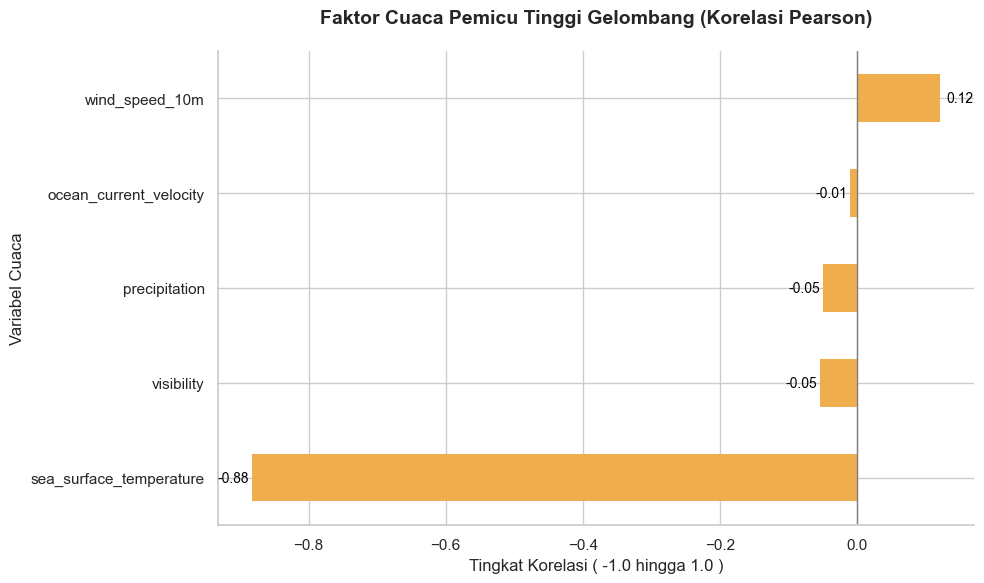

In [7]:
plt.figure(figsize=(10, 6))

# Memilih hanya kolom numerik
numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns

# Menghitung korelasi khusus terhadap wave_height dan mengurutkannya
corr_with_wave = df[numeric_cols].corr()['wave_height'].drop('wave_height').sort_values()

# Membuat diagram batang horizontal (Flat Design)
ax = corr_with_wave.plot(kind='barh', color=color_warning, edgecolor='none')

# Menambahkan label nilai korelasi di ujung batang
for i, v in enumerate(corr_with_wave):
    ax.text(v + (0.01 if v > 0 else -0.05), i, f"{v:.2f}", color='black', va='center', fontsize=10)

plt.title("Faktor Cuaca Pemicu Tinggi Gelombang (Korelasi Pearson)", fontsize=14, pad=20, fontweight='bold')
plt.xlabel("Tingkat Korelasi ( -1.0 hingga 1.0 )", fontsize=12)
plt.ylabel("Variabel Cuaca", fontsize=12)
plt.axvline(x=0, color='grey', linewidth=1) # Garis batas tengah
plt.tight_layout()

# Menyimpan gambar untuk laporan
os.makedirs(os.path.join("..", "reports", "figures"), exist_ok=True)
plt.savefig(os.path.join("..", "reports", "figures", "wave_correlation_bar.png"), dpi=300)
plt.show()

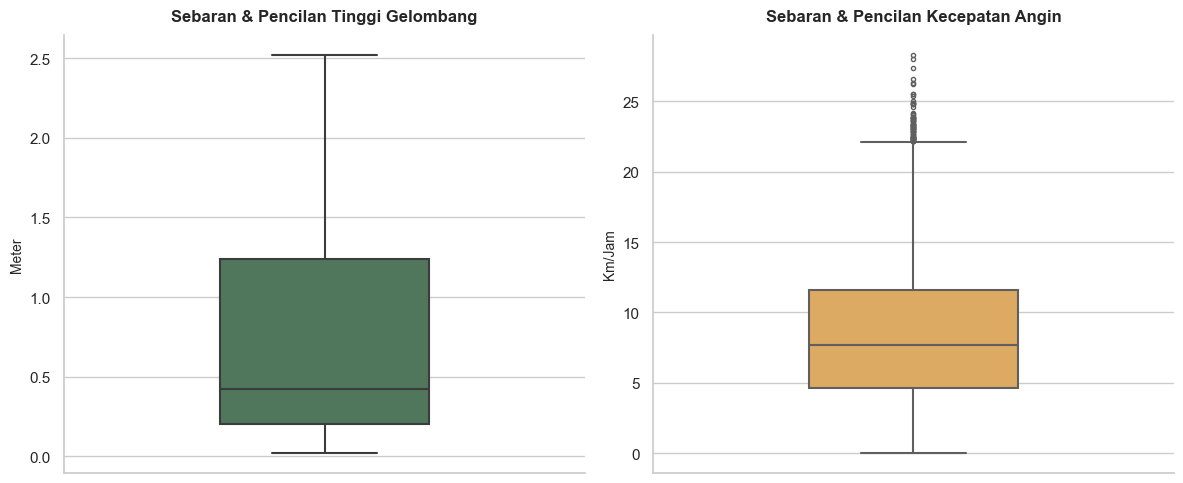

In [11]:
plt.figure(figsize=(12, 5))

# Kita buat dua boxplot berdampingan untuk dua variabel paling krusial
plt.subplot(1, 2, 1)
sns.boxplot(y=df['wave_height'], color=color_main, width=0.4, fliersize=3, linewidth=1.5)
plt.title("Sebaran & Pencilan Tinggi Gelombang", fontsize=12, pad=10, fontweight='bold')
plt.ylabel("Meter", fontsize=10)

plt.subplot(1, 2, 2)
sns.boxplot(y=df['wind_speed_10m'], color=color_warning, width=0.4, fliersize=3, linewidth=1.5)
plt.title("Sebaran & Pencilan Kecepatan Angin", fontsize=12, pad=10, fontweight='bold')
plt.ylabel("Km/Jam", fontsize=10)

plt.tight_layout()

# Menyimpan gambar untuk laporan
plt.savefig(os.path.join("..", "reports", "figures", "weather_outliers_boxplot.png"), dpi=300)
plt.show()

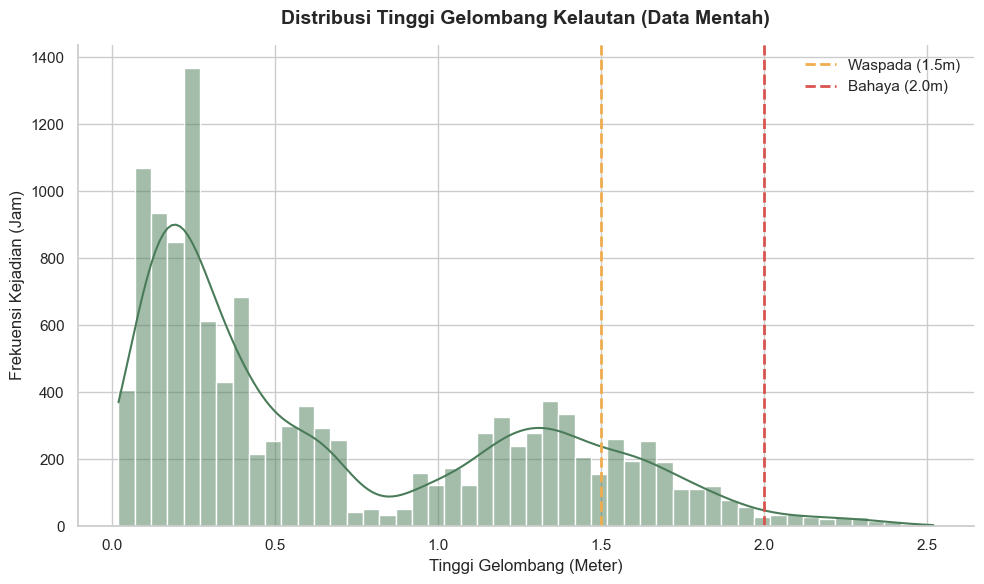

In [12]:
plt.figure(figsize=(10, 6))

# Plot distribusi dari data mentah (otomatis mengabaikan nilai kosong/NaN)
sns.histplot(df['wave_height'].dropna(), bins=50, kde=True, color=color_main, edgecolor='white')

# Menambahkan garis ambang batas bahaya (Merujuk standar WMO/BMKG)
plt.axvline(x=1.5, color=color_warning, linestyle='--', linewidth=2, label='Waspada (1.5m)')
plt.axvline(x=2.0, color=color_danger, linestyle='--', linewidth=2, label='Bahaya (2.0m)')

plt.title("Distribusi Tinggi Gelombang Kelautan (Data Mentah)", fontsize=14, pad=15, fontweight='bold')
plt.xlabel("Tinggi Gelombang (Meter)", fontsize=12)
plt.ylabel("Frekuensi Kejadian (Jam)", fontsize=12)
plt.legend()
plt.tight_layout()

plt.savefig(os.path.join("..", "reports", "figures", "wave_distribution_raw.png"), dpi=300)
plt.show()